# Transfer Learning

## Start with the problem: useful labels are scarce

Suppose we need to recognize a new set of handwritten digits, but only have 20 labeled training images per class. A CNN trained from random weights must learn both local visual patterns and the final class distinctions from those few examples. Can features learned on a related task provide a better starting point?

**Transfer learning** reuses information learned on a source task for a target task. A CNN's early layers can learn local visual patterns that are useful beyond the source labels. We can reuse those layers, replace the classification head, and either keep the feature extractor fixed or adapt it using target labels. Whether this helps is an experimental question, not a guarantee.

This CPU project trains a source CNN on bundled images of digits zero through four, then transfers its feature extractor to classify five through nine. Source and target use different image rows and different class sets. No pretrained downloads, credentials, or earlier notebook execution are needed. This small local pretraining experiment illustrates the mechanism; it does not reproduce the scale or diversity of a large pretrained image model.

Run the [code companion](18_Transfer_Learning.ipynb) to reproduce the experiment. The [image-classification lesson](17_Image_Classification_with_CNNs_Notes.ipynb) explains the complete CNN training workflow.

## See which knowledge is reused

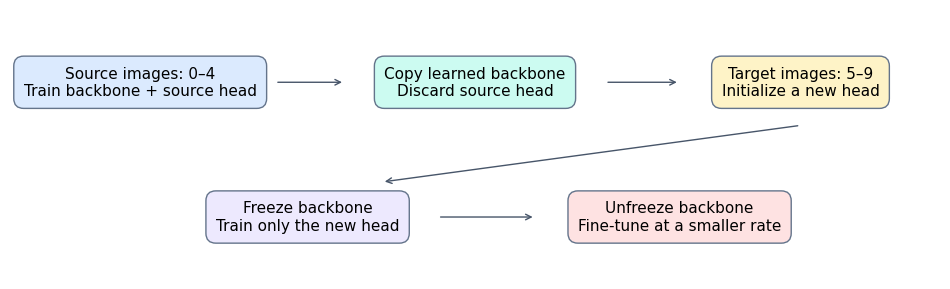

The head changes because the label meanings change. The backbone first stays fixed, then may adapt to target errors. The scratch comparison starts with a random backbone.

## Separate the feature extractor from the task-specific head

Write a classifier as $z=g_\phi(f_\theta(x))$. The input image is $x$. The backbone $f_\theta$ computes features $h$ using parameters $\theta$. The head $g_\phi$ converts those features to logits $z$ using parameters $\phi$.

Source training adjusts both parts to recognize digits 0–4. For the target task, we copy only the backbone and initialize a new head for digits 5–9. Both heads happen to output five numbers, but their class meanings differ. Keeping the source head merely because its shape fits would silently reuse the wrong associations.

For target training, index zero means digit five, one means six, two means seven, three means eight, and four means nine. Cross-entropy expects these indices from zero to four. Stored class names translate the predicted index back to the intended digit.

**Feature extraction** freezes the copied backbone and trains only the new head. **Fine-tuning** also updates some or all copied backbone weights, typically with a smaller learning rate. **Training from scratch** learns both parts from a random initialization. We compare all three on the same target splits.

## Work through a frozen-feature update completely

This two-class miniature is separate from the five-class experiment. Input $x=[1,2]$ passes through a hand-set backbone matrix $B=[[0,1],[1,0]]$ and ReLU. Its features are $h=[0(1)+1(2),1(1)+0(2)]=[2,1]$; both are positive.

The new head has weight rows $[0.1,0.2]$ and $[-0.1,0]$, with zero biases. Its logits are $[0.1(2)+0.2(1),-0.1(2)+0(1)]=[0.4,-0.2]$. Softmax gives approximately $[0.645656,0.354344]$. If the target is class one, the loss is $-\ln(0.354344)\approx1.037488$.

The derivative with respect to the logits is probability minus one-hot target: $d=[0.645656,-0.645656]$. Each head weight receives $d_i$ times its input feature, so

$$\nabla_W L\approx\begin{bmatrix}1.291313&0.645656\\-1.291313&-0.645656\end{bmatrix},\qquad \nabla_bL=d.$$

An SGD step at rate $0.1$ gives head weight rows approximately $[-0.029131,0.135434]$ and $[0.029131,0.064566]$, and biases $[-0.064566,0.064566]$. The backbone remains exactly $B$ and still returns $[2,1]$.

Using full-precision updated values, new logits are approximately $[0.012606,0.187394]$. The new head now chooses class one. The mechanism is learning how to use a fixed representation; the representation itself has not changed.

Why can this help? The new task can learn a relatively small number of head parameters instead of relearning all visual features. Why can it fail? If the fixed representation has discarded information needed for the new labels, no head can recover that missing information.

## Understand what fine-tuning adds to that calculation

Return to the miniature's original weights. The derivative reaching each feature is $W^Td$. Here it is $[0.1(0.645656)+(-0.1)(-0.645656),0.2(0.645656)+0(-0.645656)]\approx[0.129131,0.129131]$.

Both backbone preactivations are positive, so ReLU passes these derivatives. Each backbone row multiplies input $[1,2]$, giving

$$\nabla_B L\approx\begin{bmatrix}0.129131&0.258263\\0.129131&0.258263\end{bmatrix}.$$

If this backbone is unfrozen and its rate is $0.01$, its updated matrix is approximately $[[-0.001291,0.997417],[0.998709,-0.002583]]$. Its new features become $[1.993543,0.993543]$. The target task can now change what the representation retains, not only how the head reads it. A small rate can limit the size of early changes, but it does not mathematically guarantee preservation of useful source features.

`requires_grad_(False)` controls whether gradients are accumulated for parameters. `eval()` instead controls behaviors such as dropout and BatchNorm. They are different operations. With BatchNorm, frozen weights alone do not stop running-statistic updates in training mode. Our backbone has neither BatchNorm nor dropout, but the frozen training routine explicitly keeps it in evaluation mode to demonstrate the intended contract.

## Protect the target evaluation before learning anything

Source images are digits 0–4; target images are digits 5–9. We split the source into 80% training and 20% validation. Source validation selects the source checkpoint without consulting target results.

Within the target images, reserve 20% for testing and one quarter of the remainder for validation. From the remaining target training pool, choose exactly 20 examples per class, giving 100 labeled target training images. The unused target training-pool images stay unused; we do not add them to source pretraining. This models label scarcity deliberately.

Every split is stratified and seeded. We check that source, target training, target validation, and target test row indices cannot overlap. Pixel values are divided by the fixed dataset maximum 16, so no preprocessing statistic is fitted on validation or test data.

This is a class-disjoint, same-domain transfer experiment. The bundled loader does not provide writer groups for these splits, so row disjointness does not establish independence of handwriting styles or near-duplicate drawings. The validation budget is also substantial relative to the 100 training images; a genuinely label-scarce deployment must count labels used for selection too.

## Inspect the source and target tasks

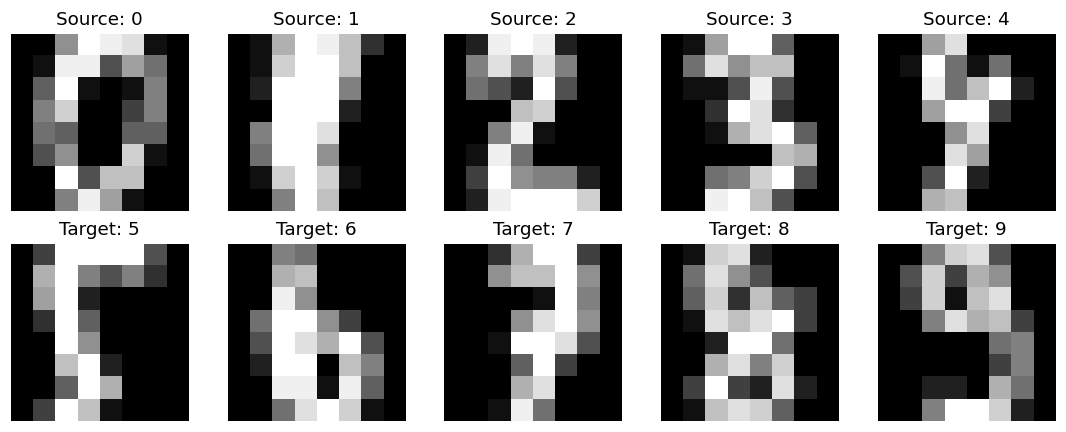

Source examples show digits zero through four; target examples show five through nine. Only training examples are displayed.

## Use an architecture with a reusable boundary

The backbone is Conv(1 → 8) → ReLU → MaxPool → Conv(8 → 16) → ReLU → MaxPool → Flatten. Both convolutions use 3 × 3 filters with padding one. An 8 × 8 image becomes eight 4 × 4 maps after the first pool, then sixteen 2 × 2 maps after the second, yielding 64 features.

The five-class head is a linear map from 64 features to five logits. Backbone parameters are $8(1\times3\times3+1)+16(8\times3\times3+1)=80+1168=1248$. Head parameters are $5(64+1)=325$. Total: $1573$.

During frozen feature extraction, only 325 parameters can change. During full fine-tuning or scratch training, all 1,573 can change. Freezing reduces gradient and optimizer work, but a forward computation is still required to obtain features. If preprocessing is deterministic, frozen features could be cached; this notebook recomputes them to keep all methods in one transparent training routine.

## Learn source features and save the validation choice

Source training sees only source labels and images. Adam updates both backbone and head for 30 epochs. We evaluate training and validation cross-entropy after each epoch, including the initial state, and deep-copy the lowest-validation-loss state. This selection uses no target validation or test information.

The reusable knowledge is the selected backbone's parameter values, not the optimizer's momentum records or the source label mapping. We use new optimizers for the target tasks. The target head is also new, even though its shape matches the source head.

A pretrained model has already consumed data and computation. Transfer should not be described as getting that knowledge for free. In this experiment we explicitly perform the source work so its origin is visible.

## Train a new head while proving that the backbone stays fixed

Copy the selected source backbone into a new target model. Initialize a new five-class head and use target index zero for digit five, not digit zero. Set backbone parameters to `requires_grad=False` and build the optimizer from head parameters only.

The target loss still changes when the head changes, even though every image's backbone features stay fixed. After training, we compare every backbone tensor exactly to its starting value and confirm that its gradients stayed absent. This verifies freezing rather than relying on a label in the code.

The frozen stage uses 30 target epochs. With 100 images and batches of 32, that is four updates per epoch, or 120 updates. We keep its best validation checkpoint as both an evaluated method and the starting point for fine-tuning.

## Fine-tune gently and compare with an equal target-epoch scratch run

Start fine-tuning from the selected frozen model, re-enable backbone gradients, and create a new optimizer with two parameter groups: backbone rate `0.0003`, head rate `0.003`. The backbone can now adapt to target distinctions while the head continues learning. We fine-tune for 30 more target epochs and allow the starting frozen checkpoint to win validation selection if adaptation does not help.

For the scratch comparison, use a randomly initialized backbone and the exact same initial target-head values used by the frozen method. Train all parameters for 60 target epochs. Both the transfer pipeline (30 frozen + 30 fine-tuning) and scratch therefore perform 240 target minibatch updates. The frozen-only result uses 120 updates and represents the intermediate, cheaper option.

This controls target update count, not total compute or information: transfer also used source training, and only one set of learning-rate choices and one data split are evaluated. A difference here cannot establish that transfer always wins. The target test set remains unopened until all methods are fixed.

## Compare learning within each stage

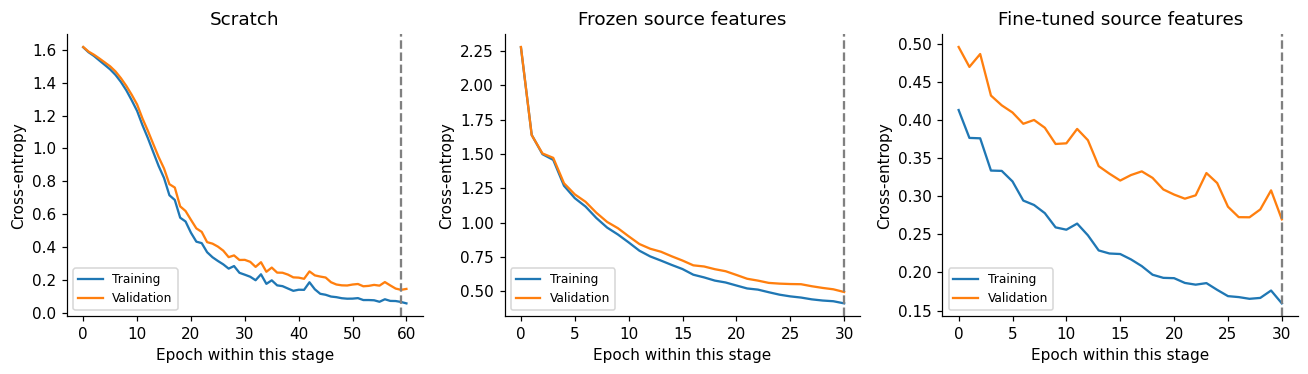

Fine-tuning starts from the selected frozen checkpoint; its epoch zero is not a random model. Each vertical line marks a validation-selected state.

## Judge the fixed methods on target images they never trained on

Now evaluate each fixed method on the same target test images. Accuracy is correct predictions divided by test count. Cross-entropy is the mean $-\ln p_{true}$, which also penalizes confident mistakes. We report both rather than judging a small dataset from one number.

The method to save is selected by target validation loss before test evaluation. Reporting test results for the other predeclared methods is a comparison, not permission to replace the validation decision with whichever test score looks best. Confusion matrices show actual digits on rows and predicted digits on columns.

Transfer can hurt when source patterns are irrelevant or when the source representation suppresses useful target information. This is **negative transfer**. Fine-tuning can repair some mismatch but can also overfit or overwrite useful features. A frozen baseline and a scratch baseline help identify what the observed gain, if any, comes from. More splits and stronger controls would be needed for a general claim.

## Read the held-out confusion matrices

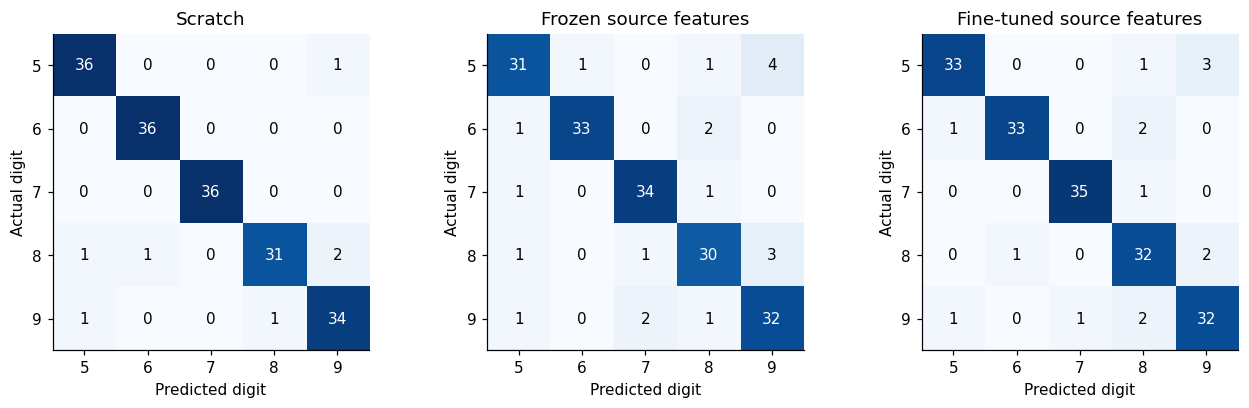

Rows show actual target digits; columns show predicted target digits. All methods use the same test split and color scale.

## Reuse a prediction with the correct target meaning

For a target example, the output's largest index must be translated using `['5', '6', '7', '8', '9']`. A head output at index one means six, not one. This mapping is just as important as the numerical weights.

Save the validation-selected model with its architecture identifier, target classes, pixel scale, and expected image shape. The save/restore check rebuilds the network and preprocessing from that metadata and verifies the same probabilities. It does not need the source classifier head or an optimizer to make a target prediction.

The checkpoint is temporary so the lesson leaves no model files behind. For real reuse, choose a persistent destination and preserve the same input conventions. Loading a pretrained model elsewhere also requires matching its channel order, resizing, and normalization; substituting arbitrary preprocessing can invalidate the learned features.

## Read the saved reference run

The source checkpoint was selected at epoch 30. Target validation selected **Scratch** as the method to save, before opening the target test set. All target methods learned from 100 labeled training images; target validation used 179 images.

| Method | Selected stage epoch | Correct on target test | Accuracy | Cross-entropy |
| --- | --- | --- | --- | --- |
| Scratch | 59 | 173/180 | 96.1% | 0.168236 |
| Frozen source features | 30 | 160/180 | 88.9% | 0.513456 |
| Fine-tuned source features | 30 | 165/180 | 91.7% | 0.266830 |

Stage epochs are local to each training phase. Scratch ran 60 target epochs; frozen-head training ran 30; fine-tuning ran 30 more after the frozen phase. Both full pipelines made 240 target updates, but transfer also used source pretraining. This single-split result is evidence about this experiment, not a guaranteed ranking. The frozen-state and save/restore checks passed.

In this run, fine-tuning improved on the frozen-feature result, but neither transfer method beat scratch. This does not isolate the cause: source-task suitability, learning rates, initialization, and the short adaptation schedule may all contribute. We did not retune using the test results. The lesson is to verify the value of a reused representation rather than assume it.

## Understand what transferred and what the experiment cannot prove

The backbone transferred numerical feature-extraction rules learned from source examples. It did not transfer an abstract understanding of handwriting. Frozen training learned how to read those features for different labels; fine-tuning let target errors reshape them. The explicit arithmetic shows how both operations work.

All three methods use the same 100 target training images. The transfer pipeline and scratch run have equal target minibatch counts, while transfer additionally consumes source examples and pretraining work. Frozen-only training is a lower-cost intermediate result. Validation makes all checkpoint and final-method choices, while the test split describes their fixed performance.

A single class-disjoint split within one small dataset is limited evidence. Broader source data, a different target domain, more target labels, or different hyperparameters can change the ranking. Fine-tuning may also reduce source-task performance; this project does not evaluate retention of the discarded source head. Choose transfer because held-out target evidence supports it, not because pretrained weights are automatically better.